# **Lab 2, Part II: Image processing: Color models**  

**This is the second part of Lab 2.**

**You must submit a single lab report covering both Part I and Part II of this lab.**


In this lab, you will explore essential image processing techniques that transform and enhance images, allowing you to extract meaningful insights. These foundational operations serve as building blocks for more advanced computer vision applications.  

### **What you will learn in this Lab:**  
- You will understand the principles behind **geometric transformations and logical operations** in image processing **(Part I)**.  
- You will apply **geometric transformations** such as **resizing, rotation, translation, and perspective modification** to adjust image properties.  
- Explore **color spaces** and how to convert between different color models for advanced image processing **(Part II)**.  

---  




### Understanding the libraries used
Before starting the lab, provide a brief definition of the following libraries and their role in image processing:

- **OpenCV**: Open Source Computer Vision Library, primarily used for image and video processing tasks such as geometric transformations, filtering, and morphological operations.
  
- **NumPy**: A fundamental package for numerical computing in Python, providing support for arrays, matrices, and mathematical functions used in image processing.
  
- **Matplotlib**: A plotting library for Python that enables visualization of images, histograms, and transformations applied to images.

If not installed, you can install them using:

`pip install opencv-python numpy matplotlib`

In [1]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

# Compatibility aliases / extra imports used later in the notebook
cv2 = cv  # some cells use `cv2.*` while we imported OpenCV as `cv`
import random
import colorsys


# Manipulation 3: Color spaces

Color spaces define how colors are represented in digital images. There are diffrent color spaces **RGB, XYZ,** **L\*** **a\*** **b\***, **HSV**...

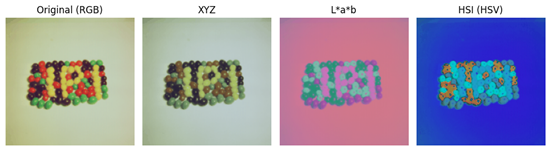

Before diving into coding, let's conduct a **short research** on color spaces.


**Let's consider the folloing color spaces:**

 1. **RGB (Red, Green, Blue)** (Additive: Colors made by mixing light;Primaries: Red, Green, Blue).
 2. **XYZ (CIE 1931)** (Based on how humans see colors i.e., Matches human color vision).
 3. **L\*a*b (CIE Lab)** (Lightness: How light or dark the color is;
Opponent: Colors in two pairs).
 4. **HSV (Hue, Saturation, Value)** (cylindrical color space that represents colors based on their shade (hue), intensity (saturation), and brightness (value),).

**For each color space, answer the following questions:**

1. **Definition**: Describe the color space?  
2. **Components**: What does each channel (e.g. R, G and B for RGB) represent?  
3. **Usage**: What is it commonly used for?  
4. **Advantages & Disadvantages**: What are the benefits and limitations of the color space?


## Task 1 :Exploring RGB Color Space

#### **T 1.1: Channel Extraction**

 **Instructions:**
1. Load the image `sun.bmp`, `After.png` , and `Jellybeans.png` (you can also use other images).
2. Use OpenCV’s `cv2.split() `function to split the image into its Red, Green, and Blue channels.
3. Display each of the individual channels (R, G, B) and grayscale images to observe how each one looks independently.


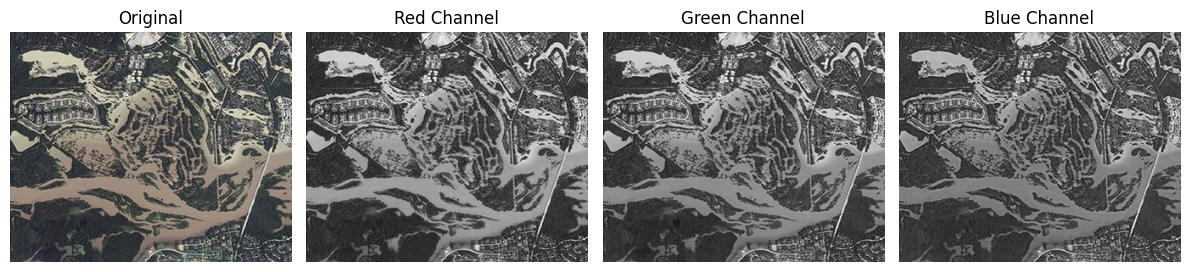

In [2]:
# T1.1: Channel Extraction

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image (make sure the file exists in the same folder)
img = cv2.imread("Images/After.png")   

# Check if image loaded correctly
if img is None:
    print("Error: Image not found. Check filename and path.")
else:
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Split channels
    b, g, r = cv2.split(img)

    # Display original and channels
    plt.figure(figsize=(12,6))

    plt.subplot(1,4,1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(r, cmap='gray')
    plt.title("Red Channel")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(g, cmap='gray')
    plt.title("Green Channel")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(b, cmap='gray')
    plt.title("Blue Channel")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

#### **T 1.2: Color Adjustment and Image Color Filtering**

In this application, we will adjust the brightness and contrast of an image by modifying the individual color channels (RGB). We will create a simple color filter by enhancing or reducing the intensity of one or more channels.

1. Load the Image `Sun.bmp`, `After.png` , and `Jellybeans.png` (You can use other images)

2. Modify the brightness and contrast of the image by adding a constant value to the channels (brightness), increase brightness by (50, 100, 255). Multipl the channels by a factor (contrast) by (1.5, 5, 10...).
3. Create a Color Filter: by enhancing or reducing the intensity of the red, green, or blue channels. Try to create the effect of *warm filter* by emphasizes `red`, and *cool filter* that typically highlights `blue` and `green`.
4. Display the original image and the resuting images.
5. Discuss the results.

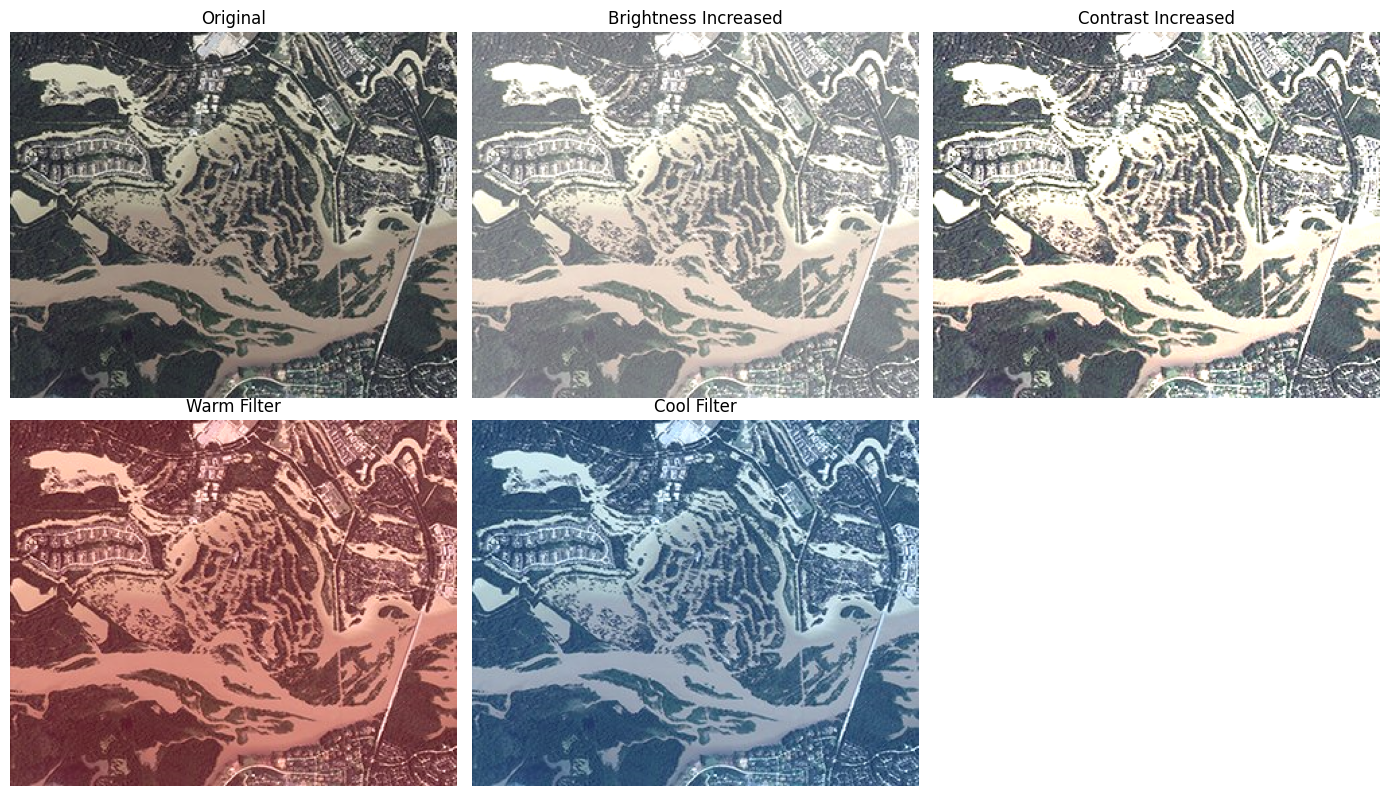

In [3]:
# Modify Brightness and Contrast..

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load correct file (CHECK EXTENSION!)
img = cv2.imread("Images/After.png")

if img is None:
    print("Error: Image not found. Check filename and extension.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_float = img.astype(np.float32)

    # Brightness
    brightness_value = 80
    bright_img = np.clip(img_float + brightness_value, 0, 255).astype(np.uint8)

    # Contrast
    contrast_factor = 1.8
    contrast_img = np.clip(img_float * contrast_factor, 0, 255).astype(np.uint8)

    # Warm Filter
    warm = img_float.copy()
    warm[:,:,2] = np.clip(warm[:,:,2] + 60, 0, 255)
    warm = warm.astype(np.uint8)

    # Cool Filter
    cool = img_float.copy()
    cool[:,:,0] = np.clip(cool[:,:,0] + 60, 0, 255)
    cool[:,:,1] = np.clip(cool[:,:,1] + 30, 0, 255)
    cool = cool.astype(np.uint8)

    # Convert for display
    bright_rgb = cv2.cvtColor(bright_img, cv2.COLOR_BGR2RGB)
    contrast_rgb = cv2.cvtColor(contrast_img, cv2.COLOR_BGR2RGB)
    warm_rgb = cv2.cvtColor(warm, cv2.COLOR_BGR2RGB)
    cool_rgb = cv2.cvtColor(cool, cv2.COLOR_BGR2RGB)

    # Display
    plt.figure(figsize=(14,8))

    plt.subplot(2,3,1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,3,2)
    plt.imshow(bright_rgb)
    plt.title("Brightness Increased")
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.imshow(contrast_rgb)
    plt.title("Contrast Increased")
    plt.axis("off")

    plt.subplot(2,3,4)
    plt.imshow(warm_rgb)
    plt.title("Warm Filter")
    plt.axis("off")

    plt.subplot(2,3,5)
    plt.imshow(cool_rgb)
    plt.title("Cool Filter")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

**Add your analysis and comments here**

## Analysis and Comments

- **Brightness Increased:** The image becomes lighter overall. Some bright areas lose detail due to saturation.

- **Contrast Increased:** Dark areas become darker and bright areas brighter. Details and edges appear more pronounced.

- **Warm Filter:** Enhancing the red channel gives the image a warmer, reddish tone, creating a sunset-like effect.

- **Cool Filter:** Increasing blue and green gives the image a cooler, bluish tone, producing a colder atmosphere.

Overall, modifying RGB channels significantly changes brightness, contrast, and the emotional appearance of the image.

#### **Challenge: Sunset Effect**

Try to make a `sunset effect` on the images `Sun1.jpg and Sun2.jpg`. Which Colors of RGB are the most important once to create this effect? How close can you get to a sunset-like color scheme?

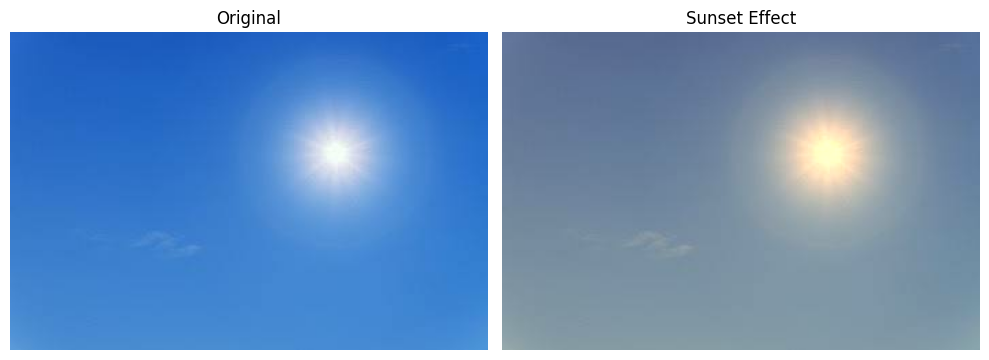

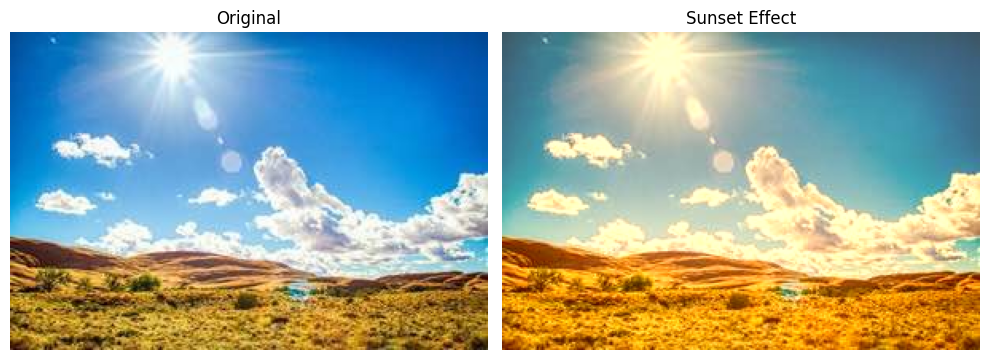

In [4]:
# Sunset Effect Code...

import cv2
import numpy as np
import matplotlib.pyplot as plt

def _read_rgb(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print(f"Could not read image: {path} (check the file name/path)")
        return None
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def sunset_effect(img_rgb, r_boost=40, g_boost=10, b_reduce=30):
    """Simple 'sunset' look: warmer highlights (more R), slightly more G, less B."""
    if img_rgb is None:
        return None
    out = img_rgb.astype(np.int16)
    out[..., 0] = np.clip(out[..., 0] + r_boost, 0, 255)   # R
    out[..., 1] = np.clip(out[..., 1] + g_boost, 0, 255)   # G
    out[..., 2] = np.clip(out[..., 2] - b_reduce, 0, 255)  # B
    return out.astype(np.uint8)

# Correct filenames + folder
for fname in ["Images/sun1.jpg", "Images/sun2.jpg"]:
    img = _read_rgb(fname)
    if img is None:
        continue

    img_sunset = sunset_effect(img, r_boost=60, g_boost=15, b_reduce=45)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Sunset Effect")
    plt.imshow(img_sunset)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

**Add your analysis and comments here**

## Analysis and Comments

- The sunset effect increases the red and slightly the green channels while reducing blue, making the image warmer.
- The sky shifts from bright blue to orange/yellow tones, simulating late afternoon or sunset lighting.
- The sunlight appears more golden and intense.
- In the second image, the landscape becomes more vibrant and warm, enhancing the dramatic atmosphere.

Overall, modifying RGB values successfully creates a realistic sunset-like effect by changing the color temperature of the image.

## Task 2 : Exploring XYZ

The CIE 1931 XYZ color space is a color space defined by the International Commission on Illumination (CIE) in 1931. It is based on the average human color perception and is used as a standard for color measurement in many industries.

#### **T 2.1. Mnipulating the XYZ Channels**

1. Convert the image `sun2.jpg`, `After.png` , and `Jellybeans.png` (You can use other images)from RGB to XYZ:

 * Rebuild the function:
   1. Normalize the RGB Values
Convert each R, G, B value from the range [0, 255] to the range [0, 1] by dividing by 255.

   2. Convert Linear RGB to XYZ

   ![Sample Image](illustrations/rgb2xyz.png)

 * Employ `openCV` function `cv2.COLOR_BGR2XYZ.`

 * Compare the results. What do you notice?

2. Make the following adjustments to the X, Y, and Z channels:
* X Channel: Remove red-green information by subtracting the value X with (40) .
* Y Channel: Add the value of (20) to increase brightness.
* Z Channel: Add the value of (100) to introduce too much yellow.
* Try diffrent combination of values and operation. How does it impact the original image.
3. Convert the modified XYZ image back to RGB using `cv2.COLOR_XYZ2BGR` and observe the changes.

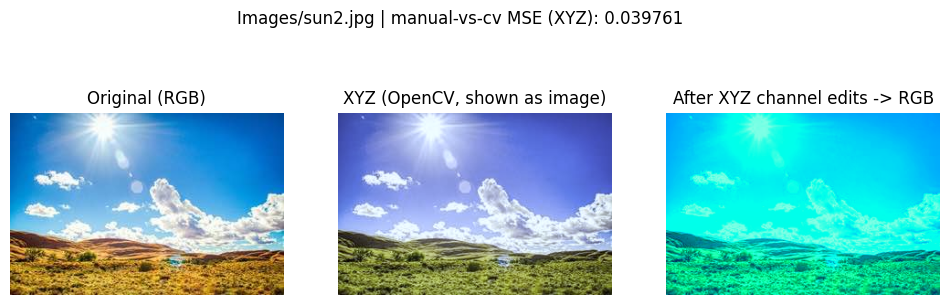

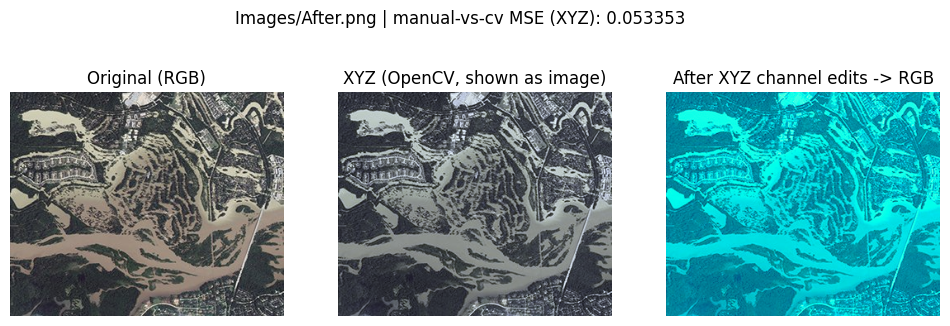

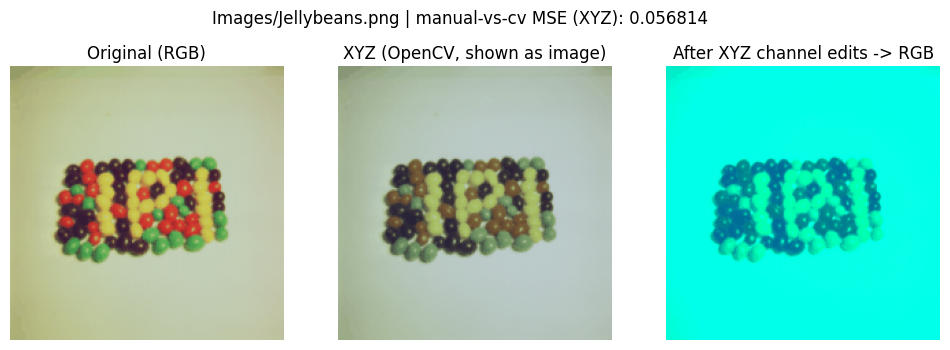

In [5]:
# XYZ Manipulation...

def rgb_to_xyz_manual(img_rgb):
    """Manual RGB -> XYZ conversion (approx. sRGB D65).
    Input: RGB uint8 image in [0,255]. Output: XYZ float image (same shape, 3 channels).
    """
    rgb = img_rgb.astype(np.float32) / 255.0

    # inverse gamma (sRGB to linear RGB)
    mask = rgb > 0.04045
    rgb_lin = np.where(mask, ((rgb + 0.055) / 1.055) ** 2.4, rgb / 12.92)

    # sRGB (D65) to XYZ matrix
    M = np.array([[0.4124564, 0.3575761, 0.1804375],
                  [0.2126729, 0.7151522, 0.0721750],
                  [0.0193339, 0.1191920, 0.9503041]], dtype=np.float32)

    xyz = rgb_lin @ M.T
    return xyz

def _read_rgb(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print(f"Could not read image: {path} (check the file name/path)")
        return None
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

for fname in ["Images/sun2.jpg", "Images/After.png", "Images/Jellybeans.png"]:
    img = _read_rgb(fname)
    if img is None:
        continue

    xyz_manual = rgb_to_xyz_manual(img)
    xyz_cv = cv2.cvtColor(img, cv2.COLOR_RGB2XYZ).astype(np.float32) / 255.0

    # Compare (rough, since OpenCV uses uint8 scaling by default)
    diff = np.mean((xyz_manual - xyz_cv) ** 2)

    # Apply requested channel edits on OpenCV XYZ (work in uint8-like domain for simplicity)
    xyz_u8 = cv2.cvtColor(img, cv2.COLOR_RGB2XYZ).astype(np.int16)
    X = np.clip(xyz_u8[..., 0] - 40, 0, 255)
    Y = np.clip(xyz_u8[..., 1] + 20, 0, 255)
    Z = np.clip(xyz_u8[..., 2] + 100, 0, 255)
    xyz_mod = np.stack([X, Y, Z], axis=-1).astype(np.uint8)
    rgb_mod = cv2.cvtColor(xyz_mod, cv2.COLOR_XYZ2RGB)

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"{fname} | manual-vs-cv MSE (XYZ): {diff:.6f}")
    plt.subplot(1, 3, 1)
    plt.title("Original (RGB)")
    plt.imshow(img); plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("XYZ (OpenCV, shown as image)")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2XYZ)); plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("After XYZ channel edits -> RGB")
    plt.imshow(rgb_mod); plt.axis("off")
    plt.show()


**Add your analysis and comments here**

## Analysis and Comments

- Converting from RGB to XYZ changes how color information is represented. The XYZ image appears slightly different because it is based on human visual perception.

- Modifying the X channel reduces red-green information, which shifts the overall color balance.

- Increasing the Y channel makes the image brighter since Y represents luminance (brightness).

- Increasing the Z channel introduces more yellow/blue influence, which explains the strong cyan/greenish appearance after converting back to RGB.

- After converting the modified XYZ image back to RGB, the colors appear significantly altered, showing how sensitive color perception is to channel manipulation in the XYZ space.

Overall, XYZ separates luminance from color information, and editing its channels produces noticeable changes in brightness and color tone.

# Challenge: The Mysterious Fog Effect

**Instruction:**

1. Convert the image `road.png` from RGB to XYZ.
2. Modify the channels:

* Increase the Y channel (brightness) by a factor (e.g., 1.5 or try other value to find the best one) but ensure it doesn’t exceed 255.
* Reduce the X channel slightly to decrease red-green contrast.
* Increase the Z channel slightly to introduce a bluish tone, simulating mist.
* Convert the modified XYZ image back to RGB and display the result.
* Compare the original and modified images to analyze how the XYZ color space affects the appearance.

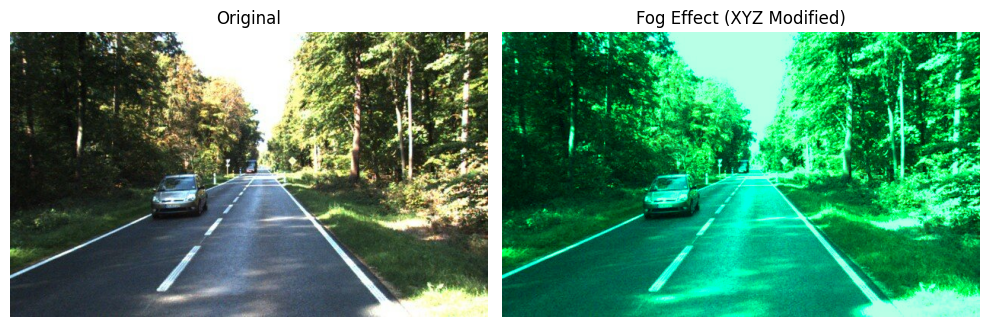

In [6]:
# Challenge: The Mysterious Fog Effect

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image (adjust path if needed)
img_bgr = cv2.imread("Images/road.png")

if img_bgr is None:
    print("Error: Image not found. Check filename/path.")
else:
    # Convert BGR to XYZ
    img_xyz = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2XYZ).astype(np.float32)

    # Split channels
    X, Y, Z = cv2.split(img_xyz)

    # --- Apply Fog Effect Modifications ---
    
    # Increase brightness (Y channel)
    Y = np.clip(Y * 1.4, 0, 255)

    # Reduce red-green contrast (X channel)
    X = np.clip(X * 0.9, 0, 255)

    # Add bluish mist tone (Z channel)
    Z = np.clip(Z * 1.2, 0, 255)

    # Merge modified channels
    fog_xyz = cv2.merge([X, Y, Z]).astype(np.uint8)

    # Convert back to BGR then RGB for display
    fog_bgr = cv2.cvtColor(fog_xyz, cv2.COLOR_XYZ2BGR)
    original_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    fog_rgb = cv2.cvtColor(fog_bgr, cv2.COLOR_BGR2RGB)

    # Display
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(original_rgb)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Fog Effect (XYZ Modified)")
    plt.imshow(fog_rgb)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


**Add your analysis and comments here**

## Analysis and Comments

- Increasing the Y channel made the image brighter, simulating light diffusion similar to fog.
- Reducing the X channel slightly decreased red-green contrast, softening some color intensity.
- Increasing the Z channel introduced a strong bluish/greenish tone, creating a mist-like atmosphere.
- The modified image appears less natural and more hazy, showing how changes in XYZ channels strongly affect color perception.

Overall, manipulating the XYZ space demonstrates how brightness and color balance can be adjusted independently to simulate environmental effects like fog.

## Task 3 : L\*a*b Manipulation

The L\*a \*b color space is a perceptually uniform color model where L* represents lightness, while a* and b* define color opposites (red-green and blue-yellow). It is widely used in color correction and image processing due to its separation of brightness and chromatic information

#### **T 3.1. Convert the Image to L\*a*b and Display Each Channel**

**Instuctions**

1. Convert `"road.png", "Earth.bmp" , and "Pepper.bmp"` (You can use other images)  from RGB to L\*a*b: Employ the predefine function `cv2.COLOR_RGB2LAB` of `OpenCV`.

2. Split the L*, a*, and b* channels.
3. Display each channel separately in color.

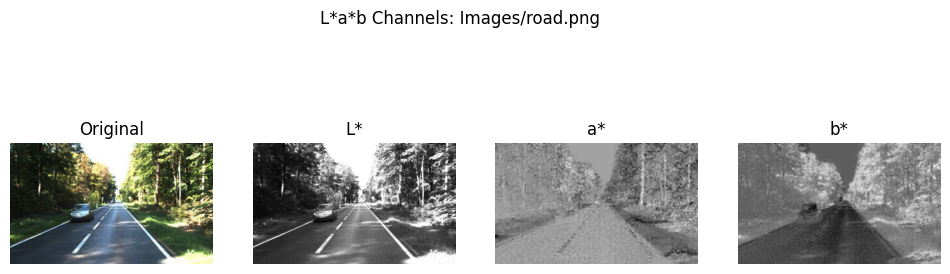

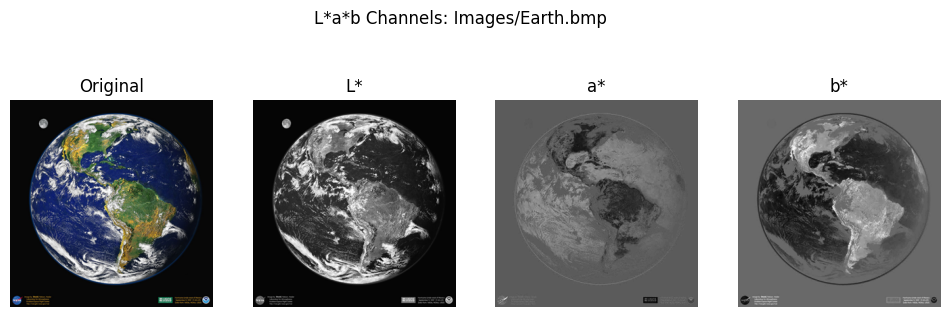

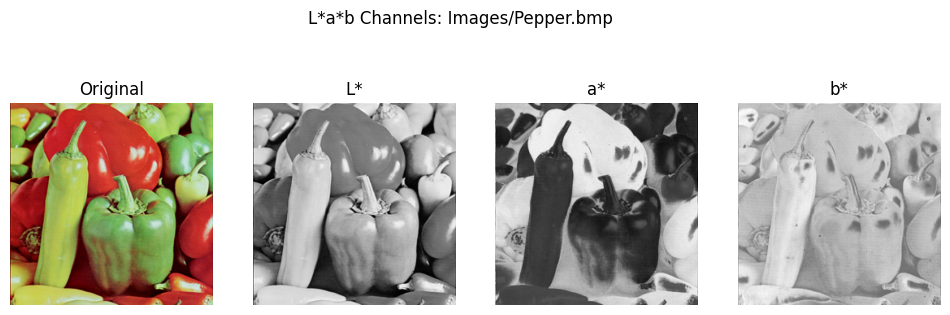

In [7]:
#L*a*b Converting...

def _read_rgb(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print(f"Could not read image: {path} (check the file name/path)")
        return None
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

for fname in ["Images/road.png", "Images/Earth.bmp", "Images/Pepper.bmp"]:
    img = _read_rgb(fname)
    if img is None:
        continue

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    L, a, b = cv2.split(lab)

    # Display each channel as a grayscale image (most informative for channels)
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"L*a*b Channels: {fname}")
    plt.subplot(1, 4, 1); plt.title("Original"); plt.imshow(img); plt.axis("off")
    plt.subplot(1, 4, 2); plt.title("L*"); plt.imshow(L, cmap="gray"); plt.axis("off")
    plt.subplot(1, 4, 3); plt.title("a*"); plt.imshow(a, cmap="gray"); plt.axis("off")
    plt.subplot(1, 4, 4); plt.title("b*"); plt.imshow(b, cmap="gray"); plt.axis("off")
    plt.show()


#### **T 3.2. Increase Decrease the Lightness**

1. Convert the image `road.png` to L\*a*b.
2. Increase the L* channel (Lightness) by 1.5x, making sure values don’t exceed 255. Decrease the L* channel (Lightness) by 1.5/, making sure values don’t exceed 255.
3. Convert back to RGB and display.
4. Try diffrent values. What do you notice?

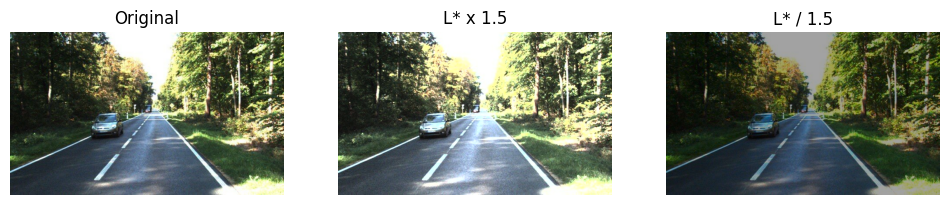

In [8]:
# Increase/ decrease L*....

img = cv2.imread("Images/road.png")
if img is None:
    print("Could not read image: road.png (check the file name/path)")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)
    L, a, b = cv2.split(lab)

    L_inc = np.clip(L * 1.5, 0, 255)
    L_dec = np.clip(L / 1.5, 0, 255)

    lab_inc = cv2.merge([L_inc, a, b]).astype(np.uint8)
    lab_dec = cv2.merge([L_dec, a, b]).astype(np.uint8)

    rgb_inc = cv2.cvtColor(lab_inc, cv2.COLOR_LAB2RGB)
    rgb_dec = cv2.cvtColor(lab_dec, cv2.COLOR_LAB2RGB)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.title("Original"); plt.imshow(img); plt.axis("off")
    plt.subplot(1, 3, 2); plt.title("L* x 1.5"); plt.imshow(rgb_inc); plt.axis("off")
    plt.subplot(1, 3, 3); plt.title("L* / 1.5"); plt.imshow(rgb_dec); plt.axis("off")
    plt.show()


**Add your analysis and comments here**

## Analysis and Comments

- Increasing the L* channel (L* × 1.5) makes the image significantly brighter while preserving the original colors, since L* controls lightness only.
- Decreasing the L* channel (L* / 1.5) makes the image darker without strongly affecting color tones.
- Unlike RGB brightness adjustment, modifying L* in L*a*b space changes illumination more naturally because brightness is separated from color information.
- The image structure and color balance remain more stable compared to direct RGB manipulation.

Overall, L*a*b allows independent control of lightness, making brightness adjustments more perceptually consistent.

#### **T 3.3.Modify the** a* and b* **Channels to Change the Image’s Color Tint**

**Instructions**

1. Convert the image `road.png` to L\*a*b.
2. Reduce the a* channel (Red-Green) to shift the image toward green.
3. Increase the b* channel (Blue-Yellow) to add a yellow tint.
4. Convert back to RGB and display
5. Try diffrent combinations. What do you notice?*italicized text*

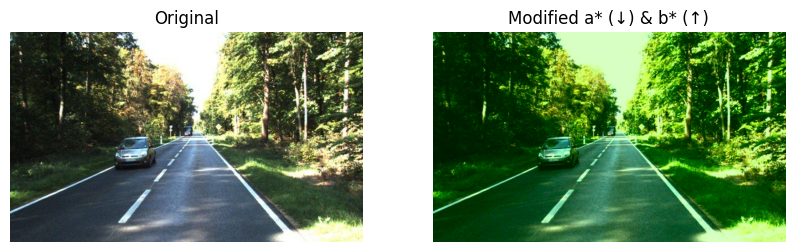

In [9]:
# Modify a*b*...

img = cv2.imread("Images/road.png")
if img is None:
    print("Could not read image: road.png (check the file name/path)")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.int16)
    L, a, b = cv2.split(lab)

    # Reduce a* to shift toward green; increase b* to add yellow tint
    a2 = np.clip(a - 30, 0, 255)
    b2 = np.clip(b + 30, 0, 255)

    lab_mod = cv2.merge([L, a2, b2]).astype(np.uint8)
    rgb_mod = cv2.cvtColor(lab_mod, cv2.COLOR_LAB2RGB)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.title("Original"); plt.imshow(img); plt.axis("off")
    plt.subplot(1, 2, 2); plt.title("Modified a* (↓) & b* (↑)"); plt.imshow(rgb_mod); plt.axis("off")
    plt.show()


**Add your analysis and comments here**

## Analysis and Comments

- Reducing the a* channel shifts the image toward green because a* controls the red–green color axis.
- Increasing the b* channel adds a yellow tint since b* represents the blue–yellow axis.
- The modified image appears greener and warmer compared to the original.
- Unlike RGB manipulation, changing a* and b* directly affects color tint without significantly altering brightness (L* remains unchanged).

Overall, the L*a*b color space allows independent control of color tones, making it effective for color correction and tint adjustments.

## Task 4: HSV Color Space

The HSV (Hue, Saturation, Value) represents colors in a way that's often more intuitive for human perception compared to the standard RGB model. *Hue (H)*
represents the type of color and is typically measured in degrees *(from 0° to 360°*). *Saturation (S)* measures the intensity or purity of the color i.e., saturation of 0 means the color is completely unsaturated (a shade of gray), while a saturation of 100% (or 1, depending on the scale) means the color is fully vibrant.Value (V) indicates the brightness of the color. A value of *0* means the color is completely dark (black), and a high value indicates a brighter, more illuminated color.

**RGB to HSV Conversion Equations**

Given an RGB color with components \( R \), \( G \), and \( B \) (ranging from 0 to 255), first normalize them to the range [0,1] :


r = R / 255;   g = G / 255 ; b = B / 255

**Step 1: Calculate Value (V)**


V = max(r, g, b)


**Step 2: Find the Minimum and Delta**

Δ = V - min(r, g, b)


**Step 3: Calculate Saturation (S)**

\begin{cases}
S = 0, & \text{if } V = 0, \\
S = \dfrac{\Delta}{V}, & \text{otherwise}.
\end{cases}



**Step 4: Calculate Hue (H)**


\begin{cases}

H = 0^\circ + 60^\circ \times \left(\dfrac{g - b}{\Delta} \right), & \text{if } V = r, \\
H = 120^\circ + 60^\circ \times \left(\dfrac{b - r}{\Delta} \right), & \text{if } V = g, \\
H = 240^\circ + 60^\circ \times \left(\dfrac{r - g}{\Delta} \right), & \text{if } V = b.
\end{cases}




#### **T 4.1. Manipulate the Image Value**

**Instructions:**

1. Convert  `"road.png", "Earth.bmp" , and "Pepper.bmp"` from RGB to HSV.
 * Rebuid the function
 * Use OpenCV predefined function `cv2.COLOR_RGB2HSV`.
 * Compare the results. What do you notice.
2. Increase the Value (V) channel by a factor (e.g., 1.8), ensuring values do not exceed their maximum allowable range.
3. Experiment with different scaling factors and observe how the brightness changes.
4. What happens when the factor is too high?
5. Convert back to RGB and display.

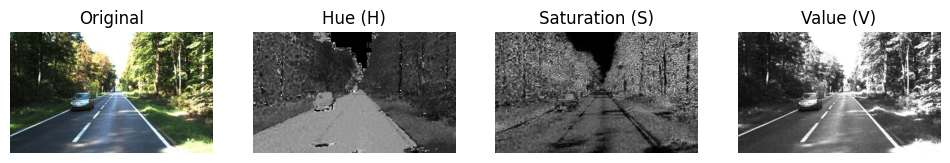

In [10]:
##HSV Value...

def _read_rgb(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print(f"Could not read image: {path} (check the file name/path)")
        return None
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img = _read_rgb("Images/road.png")
if img is not None:
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    H, S, V = cv2.split(hsv)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1); plt.title("Original"); plt.imshow(img); plt.axis("off")
    plt.subplot(1, 4, 2); plt.title("Hue (H)"); plt.imshow(H, cmap="gray"); plt.axis("off")
    plt.subplot(1, 4, 3); plt.title("Saturation (S)"); plt.imshow(S, cmap="gray"); plt.axis("off")
    plt.subplot(1, 4, 4); plt.title("Value (V)"); plt.imshow(V, cmap="gray"); plt.axis("off")
    plt.show()


**Add your analysis and comments here**

## Analysis and Comments

- In the HSV color space, the Value (V) channel represents brightness.
- Increasing the V channel makes the image brighter without directly changing hue or saturation.
- The Hue (H) channel defines the color type, while the Saturation (S) channel controls color intensity.
- When the scaling factor for V is too high, some bright areas become overexposed and lose detail due to clipping (values reaching 255).
- Compared to RGB brightness adjustment, modifying V in HSV space produces a more natural brightness change because color and intensity are separated.

Overall, HSV allows intuitive control of brightness through the V channel while preserving the original color information.

#### **T 4.2. Modify the Saturation**
 **Instruction**
1. Convert "road.png" "Before.png" (You can choose other images) from RGB to HSV.
2. Reduce the Saturation (S) channel by 40% to make the image appear washed out.
 * Ensure that the values do not drop below 0.
4. Convert the modified HSV image back to RGB and display the result.
5. Experiment with different values for S.
  * What do you notice when the saturation is very low or very high?

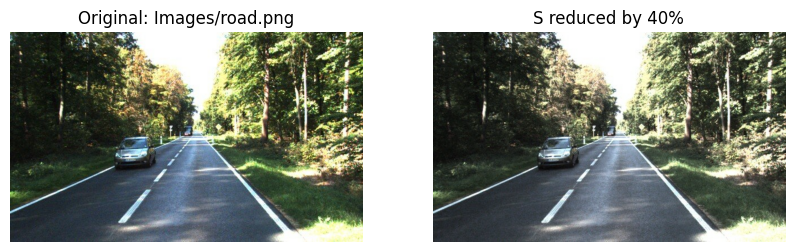

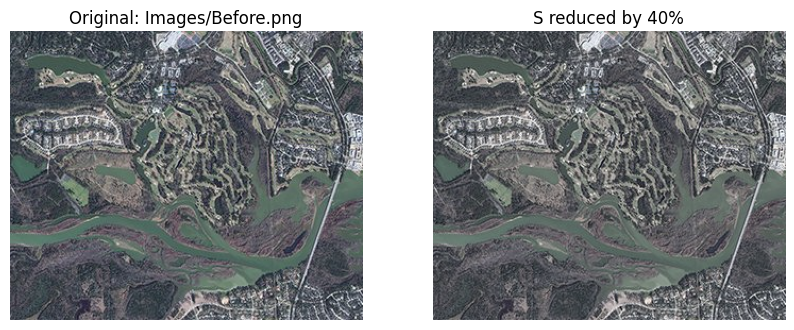

In [11]:
#HSV Saturation....

def _read_rgb(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print(f"Could not read image: {path} (check the file name/path)")
        return None
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

for fname in ["Images/road.png", "Images/Before.png"]:
    img = _read_rgb(fname)
    if img is None:
        continue
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    H, S, V = cv2.split(hsv)

    S_mod = np.clip(S * 0.6, 0, 255)  # reduce saturation by 40%
    hsv_mod = cv2.merge([H, S_mod, V]).astype(np.uint8)
    rgb_mod = cv2.cvtColor(hsv_mod, cv2.COLOR_HSV2RGB)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.title(f"Original: {fname}"); plt.imshow(img); plt.axis("off")
    plt.subplot(1, 2, 2); plt.title("S reduced by 40%"); plt.imshow(rgb_mod); plt.axis("off")
    plt.show()


**Add your analysis and comments here**

## Analysis and Comments

- Reducing the Saturation (S) channel by 40% makes the image appear less vivid and slightly washed out.
- Colors become softer and closer to gray as saturation decreases.
- The overall brightness (Value) and structure of the image remain mostly unchanged.
- When saturation is very low, the image approaches grayscale.
- When saturation is very high, colors become overly intense and may look unnatural.

Overall, the Saturation channel controls color intensity, allowing adjustment of how vivid or muted the image appears without changing brightness.


## Task 5: Pixel color estimation

### **Look at the image above:**

Your task is to **recreate the pixel color inside the red square on the right using the RGB color space components:**


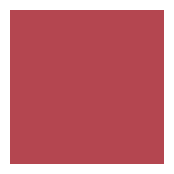

In [12]:
R = 180  # Adjust this value
G = 70   # Adjust this value
B = 80  # Adjust this value

pixel = np.zeros((100, 100, 3), dtype=np.uint8)
pixel[:, :, 0] = R
pixel[:, :, 1] = G
pixel[:, :, 2] = B


plt.figure(figsize=(2, 2))
plt.imshow(pixel)
plt.axis("off")
plt.show()


- R = 180
- G = 70
- B = 80

**Do the same as for RGB, but now using the HSV components (Hue, Saturation, Value) to match the pixel color inside the red square.**

- H = 177
- S = 156
- V = 180


#### **T 5.1: Dynamic color estimation using RGB color space components**

Load an image of your choice, and do the following steps:

- Click on a pixel within the image to select a target color.
- Adjust the RGB sliders to visually match the selected color as accurately as possible.
- Click on "Check Color" to calculate and display the Mean Squared Error (MSE) between your guess and the true color.

**Note:** MSE (Mean Squared Error) measures the average squared difference between your estimation using RGB values and the correct RGB values of the pixel. Lower MSE indicates an accurate estimation.

In [21]:
import random

from ipycanvas import Canvas, hold_canvas
import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------------------------------------------
# 1. Load and Preprocess the Image
# ------------------------------------------------------------------------------

image_path = "Images/leaning.jpg"  

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))
img_rgb = np.array(img)

# Get dimensions (should be 256x256)
height, width, _ = img_rgb.shape

img_rgba = np.zeros((height, width, 4), dtype=np.uint8)
img_rgba[..., :3] = img_rgb
img_rgba[..., 3] = 255

# ------------------------------------------------------------------------------
# 2. Create the Canvas and the "Guessed Color" Square
# ------------------------------------------------------------------------------
main_canvas = Canvas(width=width, height=height)
guess_canvas = Canvas(width=50, height=50)

main_canvas.put_image_data(img_rgba, 0, 0)

selected_color = None   
selected_coords = None  

# ------------------------------------------------------------------------------
# 4. Mouse Click Handler
# ------------------------------------------------------------------------------
def on_mouse_down(x, y):
    x = int(x)
    y = int(y)
    global selected_color, selected_coords
    if 0 <= x < width and 0 <= y < height:
        selected_coords = (x, y)
        selected_color = img_rgb[y, x]

        with hold_canvas(main_canvas):
            main_canvas.clear()
            main_canvas.put_image_data(img_rgba, 0, 0)
            main_canvas.stroke_style = "red"
            main_canvas.begin_path()
            main_canvas.move_to(x - 5, y)
            main_canvas.line_to(x + 5, y)
            main_canvas.move_to(x, y - 5)
            main_canvas.line_to(x, y + 5)
            main_canvas.stroke()

        info_label.value = f"Selected pixel at ({x}, {y}). Now guess its color!"

main_canvas.on_mouse_down(on_mouse_down)

# ------------------------------------------------------------------------------
# 5. Sliders & "Check Color" Button
# ------------------------------------------------------------------------------
slider_R = widgets.IntSlider(min=0, max=255, value=0, description='R:')
slider_G = widgets.IntSlider(min=0, max=255, value=0, description='G:')
slider_B = widgets.IntSlider(min=0, max=255, value=0, description='B:')

def update_guess_canvas(_=None):
    """Refresh the guess_canvas to reflect the current slider color."""
    guess_canvas.clear()
    guess_canvas.fill_style = f"rgb({slider_R.value}, {slider_G.value}, {slider_B.value})"
    guess_canvas.fill_rect(0, 0, 50, 50)

slider_R.observe(update_guess_canvas, 'value')
slider_G.observe(update_guess_canvas, 'value')
slider_B.observe(update_guess_canvas, 'value')
update_guess_canvas()

check_button = widgets.Button(description='Check Color')
output_result = widgets.Output()

def on_check_color_clicked(_):
    """Compute the MSE between guessed color and the selected pixel's color."""
    if selected_color is None:
        info_label.value = "No pixel selected yet!"
        return
    guess_color = np.array([slider_R.value, slider_G.value, slider_B.value], dtype=np.uint8)
    mse = np.mean((selected_color.astype(np.float32) - guess_color.astype(np.float32)) ** 2)
    with output_result:
        clear_output()
        print(f"MSE: {mse:.2f}")

check_button.on_click(on_check_color_clicked)

# ------------------------------------------------------------------------------
# 6. Layout
# ------------------------------------------------------------------------------
info_label = widgets.Label(
    "Click on the image to select a pixel. Adjust sliders to guess, then click 'Check Color'."
)

layout = widgets.VBox([
    info_label,
    widgets.HBox([
        main_canvas,
        widgets.VBox([
            widgets.Label("Guessed color:"),
            guess_canvas
        ])
    ]),
    widgets.HBox([slider_R, slider_G, slider_B, check_button]),
    output_result
])

display(layout)
update_guess_canvas()  # Ensure the guessed color is drawn immediately

# ------------------------------------------------------------------------------
# 7. Auto-select a Random Pixel on Startup
# ------------------------------------------------------------------------------
rand_x = random.randint(0, width - 1)
rand_y = random.randint(0, height - 1)
on_mouse_down(rand_x, rand_y)



### Questions

   1. Why might it be difficult to match colors precisely using RGB?
   2. How sensitive is color estimation in RGB space?



***Add your analysis and comments here***  

## Analysis and Comments

1. It is difficult to match colors precisely in RGB because small changes in R, G, or B values can significantly alter the perceived color. Human vision is sensitive to slight variations, and it is not intuitive to adjust three numeric channels independently.

2. Color estimation in RGB space is challenging because RGB does not separate brightness from color information. The three channels are highly correlated, making it harder to adjust hue, brightness, or saturation independently compared to color spaces like HSV or L*a*b*.

Overall, RGB is straightforward for representation, but not always intuitive for manual color matching.

#### **T 5.2: Dynamic color estimation using HSV space**

- Now let's perform the same task using HSV color space (Hue, Saturation, Value).

**Note:** HSV is often considered more intuitive for color adjustments. Try to see if you can achieve a lower MSE compared to the RGB sliders!


In [22]:
from ipycanvas import Canvas, hold_canvas
import ipywidgets as widgets
from IPython.display import display, clear_output
import random
import colorsys

# ------------------------------------------------------------------------------
# 1. Load and Preprocess the Image
# ------------------------------------------------------------------------------

image_path = "Images/leaning.jpg" 

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))
img_rgb = np.array(img)

# Get dimensions (should be 256x256)
height, width, _ = img_rgb.shape

proc_rgb = img_rgb.copy()

# Create a copy for display: convert to RGBA for ipycanvas
display_rgba = np.zeros((height, width, 4), dtype=np.uint8)
display_rgba[..., :3] = img_rgb
display_rgba[..., 3] = 255

# ------------------------------------------------------------------------------
# 2. Create the Canvas and the "Guessed Color" Square
# ------------------------------------------------------------------------------
main_canvas = Canvas(width=width, height=height)
guess_canvas = Canvas(width=50, height=50)

main_canvas.put_image_data(display_rgba, 0, 0)

selected_color = None  
selected_coords = None 

# ------------------------------------------------------------------------------
# 4. Mouse Click Handler
# ------------------------------------------------------------------------------
def on_mouse_down(x, y):
    x = int(x)
    y = int(y)
    global selected_color, selected_coords
    if 0 <= x < width and 0 <= y < height:
        selected_coords = (x, y)
        selected_color = proc_rgb[y, x]

        with hold_canvas(main_canvas):
            main_canvas.clear()
            main_canvas.put_image_data(display_rgba, 0, 0)
            main_canvas.stroke_style = "red"
            main_canvas.begin_path()
            main_canvas.move_to(x - 5, y)
            main_canvas.line_to(x + 5, y)
            main_canvas.move_to(x, y - 5)
            main_canvas.line_to(x, y + 5)
            main_canvas.stroke()

        info_label.value = f"Selected pixel at ({x}, {y}). Now guess its color in HSV!"

main_canvas.on_mouse_down(on_mouse_down)

# ------------------------------------------------------------------------------
# 5. Create HSV Sliders & "Check Color" Button
# ------------------------------------------------------------------------------
# HSV slider ranges: H: 0–360, S: 0–100, V: 0–100
slider_H = widgets.IntSlider(min=0, max=360, value=0, description='H:')
slider_S = widgets.IntSlider(min=0, max=100, value=0, description='S:')
slider_V = widgets.IntSlider(min=0, max=100, value=0, description='V:')

def update_guess_canvas(_=None):
    """Convert the HSV slider values to RGB and update the guessed color square."""
    h = slider_H.value / 360.0
    s = slider_S.value / 100.0
    v = slider_V.value / 100.0
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    r_int = int(round(r * 255))
    g_int = int(round(g * 255))
    b_int = int(round(b * 255))
    color_str = f"rgb({r_int}, {g_int}, {b_int})"
    guess_canvas.clear()
    guess_canvas.fill_style = color_str
    guess_canvas.fill_rect(0, 0, 50, 50)

slider_H.observe(update_guess_canvas, 'value')
slider_S.observe(update_guess_canvas, 'value')
slider_V.observe(update_guess_canvas, 'value')
update_guess_canvas()

check_button = widgets.Button(description='Check Color')
output_result = widgets.Output()

def on_check_color_clicked(_):
    """Convert the HSV guess to RGB and compute the MSE with the true RGB color."""
    if selected_color is None:
        info_label.value = "No pixel selected yet!"
        return
    h = slider_H.value / 360.0
    s = slider_S.value / 100.0
    v = slider_V.value / 100.0
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    guess_color = np.array([int(round(r * 255)),
                            int(round(g * 255)),
                            int(round(b * 255))], dtype=np.uint8)
    mse = np.mean((selected_color.astype(np.float32) - guess_color.astype(np.float32)) ** 2)
    with output_result:
        clear_output()
        print(f"MSE: {mse:.2f}")

check_button.on_click(on_check_color_clicked)

# ------------------------------------------------------------------------------
# 6. Layout
# ------------------------------------------------------------------------------
info_label = widgets.Label(
    "Click on the image to select a pixel. Adjust the HSV sliders to guess its color, then click 'Check Color'."
)

layout = widgets.VBox([
    info_label,
    widgets.HBox([
        main_canvas,
        widgets.VBox([
            widgets.Label("Guessed color:"),
            guess_canvas
        ])
    ]),
    widgets.HBox([slider_H, slider_S, slider_V, check_button]),
    output_result
])

display(layout)
update_guess_canvas()

# ------------------------------------------------------------------------------
# 7. Auto-select a Random Pixel on Startup
# ------------------------------------------------------------------------------
rand_x = random.randint(0, width - 1)
rand_y = random.randint(0, height - 1)
on_mouse_down(rand_x, rand_y)

### Question :

How does the HSV model compare to RGB in terms of intuitiveness when selecting colors?


***Add your analysis and comments here***  

## Analysis and Comments

The HSV model is generally more intuitive than RGB when selecting colors. In HSV, Hue directly represents the type of color (e.g., red, blue, green), Saturation controls how vivid or dull the color appears, and Value controls brightness. These components align more closely with how humans naturally describe colors.

In contrast, RGB requires adjusting three correlated channels simultaneously, which makes manual color selection less intuitive. Small changes in R, G, or B can significantly alter the perceived color, making fine-tuning more difficult.

Overall, HSV provides a more user-friendly and perceptually meaningful way to select and adjust colors compared to RGB.

#### **T 5.3: Estimate a color based on your perception**

Try to estimate the pixel color from an image displayed through the projector. You need to estimate that color using both color spaces RGB and HSV:

### RGB space:
- R = 120  
- G = 170  
- B = 220  

### HSV space:
- H = 105  
- S = 115  
- V = 220  

---


## Optional Task:

The **RGB color space** is not **perceptually uniform**, meaning that colors that appear **visually similar** may have **very different numerical values** (a large Euclidian distance between thir pixels), and vice-versa. This non-linearity can lead to unexpected results when calculating differences between colors.

You have to do the following steps:

1. Find at least three examples where two colors that appear **very similar** to the human eye have a **large distance**.
2. Find another three examples where two colors that appear **very different** have a **small distance**.
3. Explain why this happens by considering **human color perception** versus **numerical differences in RGB space**.


Similar reds (brightness change)
  A = (200, 60, 60), B = (140, 20, 20), RGB distance = 82.46

Similar blues (brightness change)
  A = (70, 160, 230), B = (20, 110, 180), RGB distance = 86.60

Similar greens (brightness change)
  A = (70, 200, 80), B = (20, 150, 30), RGB distance = 86.60



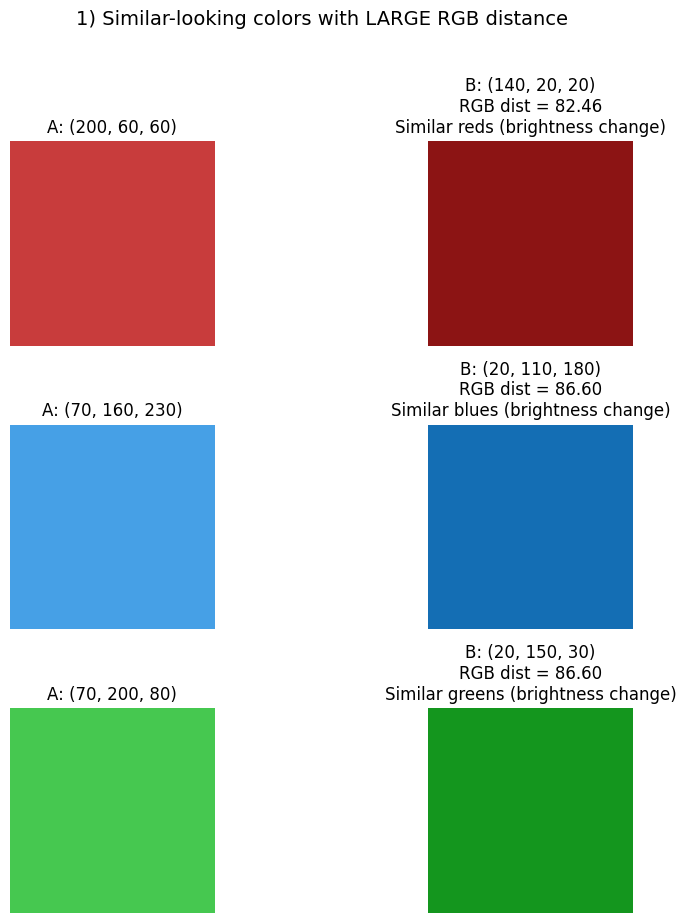

Dark gray -> slightly brighter (small dist, visible)
  A = (10, 10, 10), B = (20, 20, 20), RGB distance = 17.32

Near-white -> slightly darker (small dist, visible)
  A = (250, 250, 250), B = (240, 240, 240), RGB distance = 17.32

Blue -> bluish-cyan tint (small dist, visible)
  A = (0, 0, 255), B = (0, 20, 255), RGB distance = 20.00



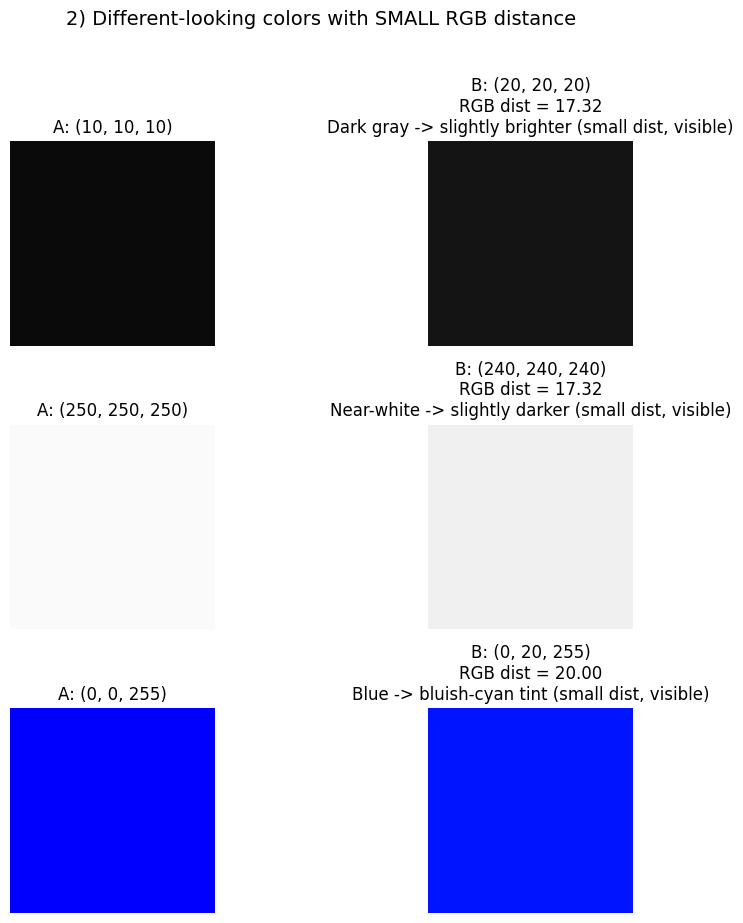

Explanation:
- RGB distance is purely numeric and does not match human perception.
- Human vision is more sensitive to brightness changes and some hues than others.
- Perceptual spaces like L*a*b* are designed to better match perceived differences.


In [23]:
import numpy as np
import matplotlib.pyplot as plt

def rgb_distance(c1, c2):
    c1 = np.array(c1, dtype=np.float32)
    c2 = np.array(c2, dtype=np.float32)
    return float(np.linalg.norm(c1 - c2))

# 1) Similar-looking (same hue, different brightness) -> can have large RGB distance
similar_large = [
    ((200, 60, 60), (140, 20, 20), "Similar reds (brightness change)"),
    ((70, 160, 230), (20, 110, 180), "Similar blues (brightness change)"),
    ((70, 200, 80), (20, 150, 30), "Similar greens (brightness change)"),
]

# 2) Different-looking (tiny changes near extremes or low-light) -> small RGB distance but visible
different_small = [
    ((10, 10, 10), (20, 20, 20), "Dark gray -> slightly brighter (small dist, visible)"),
    ((250, 250, 250), (240, 240, 240), "Near-white -> slightly darker (small dist, visible)"),
    ((0, 0, 255), (0, 20, 255), "Blue -> bluish-cyan tint (small dist, visible)"),
]

def show_pairs(pairs, title):
    n = len(pairs)
    plt.figure(figsize=(10, 3*n))
    plt.suptitle(title, y=1.02, fontsize=14)

    for i, (c1, c2, note) in enumerate(pairs):
        dist = rgb_distance(c1, c2)

        # show two color squares
        patch1 = np.zeros((60, 60, 3), dtype=np.uint8); patch1[:] = c1
        patch2 = np.zeros((60, 60, 3), dtype=np.uint8); patch2[:] = c2

        ax1 = plt.subplot(n, 2, 2*i+1)
        ax1.imshow(patch1)
        ax1.set_title(f"A: {c1}")
        ax1.axis("off")

        ax2 = plt.subplot(n, 2, 2*i+2)
        ax2.imshow(patch2)
        ax2.set_title(f"B: {c2}\nRGB dist = {dist:.2f}\n{note}")
        ax2.axis("off")

        print(f"{note}")
        print(f"  A = {c1}, B = {c2}, RGB distance = {dist:.2f}\n")

    plt.tight_layout()
    plt.show()

show_pairs(similar_large, "1) Similar-looking colors with LARGE RGB distance")
show_pairs(different_small, "2) Different-looking colors with SMALL RGB distance")

print("Explanation:")
print("- RGB distance is purely numeric and does not match human perception.")
print("- Human vision is more sensitive to brightness changes and some hues than others.")
print("- Perceptual spaces like L*a*b* are designed to better match perceived differences.")